# Half-Body Humanoid — Ball Detection & Kick
### PyBullet + OpenCV HSV Detection + Kinematics Visualization

```
L1 = 0.065 m  (upper leg / thigh)
L2 = 0.055 m  (lower leg / shin)
L3 = 0.015 m  (foot)
```

**Pipeline:**
1. Robot walks toward a red ball
2. OpenCV HSV filter detects the ball in rendered frames
3. IK computes kick trajectory
4. Robot executes kick — ball flies!
5. Full FK/IK diagram + joint plots exported

---

## 📦 Step 1 — Install & Import

In [ ]:
!pip install pybullet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
!pip install pillow opencv-python-headless -q


In [1]:
import pybullet as p
import pybullet_data
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch, Circle
import matplotlib.patheffects as pe
import cv2
from PIL import Image as PILImage
from IPython.display import display, Image as IPImage
import warnings
warnings.filterwarnings('ignore')

# Robot link lengths
L1 = 0.065   # thigh
L2 = 0.055   # shin
L3 = 0.015   # foot
TIME_STEP = 1.0 / 240.0

print('✅ Imports done!')
print(f'   L1={L1*100:.1f}cm  L2={L2*100:.1f}cm  L3={L3*100:.1f}cm')

ModuleNotFoundError: No module named 'pybullet'

## 🏗️ Step 2 — URDF Robot Model

In [ ]:
urdf_content = """
<?xml version="1.0"?>
<robot name="half_humanoid">
  <material name="black_pla"><color rgba="0.08 0.08 0.08 1.0"/></material>
  <material name="blue_servo"><color rgba="0.1 0.35 0.85 1.0"/></material>
  <material name="white_horn"><color rgba="0.92 0.92 0.92 1.0"/></material>
  <material name="dark_frame"><color rgba="0.15 0.15 0.18 1.0"/></material>

  <!-- PELVIS -->
  <link name="pelvis">
    <inertial><origin xyz="0 0 0" rpy="0 0 0"/><mass value="0.10"/>
      <inertia ixx="0.0002" ixy="0" ixz="0" iyy="0.0002" iyz="0" izz="0.0002"/></inertial>
    <visual><origin xyz="0 0 0" rpy="0 0 0"/>
      <geometry><box size="0.10 0.055 0.022"/></geometry>
      <material name="dark_frame"/></visual>
    <collision><geometry><box size="0.10 0.055 0.022"/></geometry></collision>
  </link>

  <!-- ===== LEFT LEG ===== -->
  <joint name="left_hip_roll" type="revolute">
    <parent link="pelvis"/><child link="left_hip_roll_link"/>
    <origin xyz="0.030 0.0 -0.011" rpy="0 0 0"/><axis xyz="1 0 0"/>
    <limit lower="-0.523" upper="0.523" effort="1.5" velocity="6.28"/>
    <dynamics damping="0.008" friction="0.003"/>
  </joint>
  <link name="left_hip_roll_link">
    <inertial><mass value="0.009"/>
      <inertia ixx="0.000001" ixy="0" ixz="0" iyy="0.000001" iyz="0" izz="0.000001"/></inertial>
    <visual><geometry><cylinder radius="0.007" length="0.012"/></geometry>
      <material name="blue_servo"/></visual>
    <collision><geometry><sphere radius="0.008"/></geometry></collision>
  </link>

  <joint name="left_hip_pitch" type="revolute">
    <parent link="left_hip_roll_link"/><child link="left_upper_leg"/>
    <origin xyz="0 0 0" rpy="0 0 0"/><axis xyz="0 1 0"/>
    <limit lower="-1.309" upper="1.309" effort="1.5" velocity="6.28"/>
    <dynamics damping="0.008" friction="0.003"/>
  </joint>
  <link name="left_upper_leg">
    <inertial><origin xyz="0 0 -0.0325" rpy="0 0 0"/><mass value="0.022"/>
      <inertia ixx="0.0000025" ixy="0" ixz="0" iyy="0.0000025" iyz="0" izz="0.0000006"/></inertial>
    <visual><origin xyz="0 0 -0.0325" rpy="0 0 0"/>
      <geometry><box size="0.013 0.013 0.065"/></geometry>
      <material name="black_pla"/></visual>
    <visual><origin xyz="0.011 0 -0.004" rpy="0 1.5708 0"/>
      <geometry><cylinder radius="0.006" length="0.010"/></geometry>
      <material name="blue_servo"/></visual>
    <visual><origin xyz="0.015 0 -0.004" rpy="0 1.5708 0"/>
      <geometry><cylinder radius="0.005" length="0.004"/></geometry>
      <material name="white_horn"/></visual>
    <collision><origin xyz="0 0 -0.0325" rpy="0 0 0"/>
      <geometry><box size="0.013 0.013 0.065"/></geometry></collision>
  </link>

  <joint name="left_knee" type="revolute">
    <parent link="left_upper_leg"/><child link="left_lower_leg"/>
    <origin xyz="0 0 -0.065" rpy="0 0 0"/><axis xyz="0 1 0"/>
    <limit lower="0" upper="2.094" effort="1.5" velocity="6.28"/>
    <dynamics damping="0.008" friction="0.003"/>
  </joint>
  <link name="left_lower_leg">
    <inertial><origin xyz="0 0 -0.0275" rpy="0 0 0"/><mass value="0.016"/>
      <inertia ixx="0.0000018" ixy="0" ixz="0" iyy="0.0000018" iyz="0" izz="0.0000004"/></inertial>
    <visual><origin xyz="0 0 -0.0275" rpy="0 0 0"/>
      <geometry><box size="0.012 0.012 0.055"/></geometry>
      <material name="black_pla"/></visual>
    <visual><origin xyz="0.010 0 -0.002" rpy="0 1.5708 0"/>
      <geometry><cylinder radius="0.006" length="0.010"/></geometry>
      <material name="blue_servo"/></visual>
    <visual><origin xyz="0.014 0 -0.002" rpy="0 1.5708 0"/>
      <geometry><cylinder radius="0.005" length="0.004"/></geometry>
      <material name="white_horn"/></visual>
    <collision><origin xyz="0 0 -0.0275" rpy="0 0 0"/>
      <geometry><box size="0.012 0.012 0.055"/></geometry></collision>
  </link>

  <joint name="left_ankle" type="fixed">
    <parent link="left_lower_leg"/><child link="left_foot"/>
    <origin xyz="0 0 -0.055" rpy="0 0 0"/>
  </joint>
  <link name="left_foot">
    <inertial><origin xyz="0.012 0 -0.0075" rpy="0 0 0"/><mass value="0.010"/>
      <inertia ixx="0.0000006" ixy="0" ixz="0" iyy="0.0000006" iyz="0" izz="0.0000006"/></inertial>
    <visual><origin xyz="0.012 0 -0.0075" rpy="0 0 0"/>
      <geometry><box size="0.042 0.022 0.015"/></geometry>
      <material name="black_pla"/></visual>
    <visual><origin xyz="0 0 0" rpy="0 0 0"/>
      <geometry><cylinder radius="0.007" length="0.004"/></geometry>
      <material name="white_horn"/></visual>
    <collision><origin xyz="0.012 0 -0.0075" rpy="0 0 0"/>
      <geometry><box size="0.042 0.022 0.015"/></geometry></collision>
  </link>

  <!-- ===== RIGHT LEG ===== -->
  <joint name="right_hip_roll" type="revolute">
    <parent link="pelvis"/><child link="right_hip_roll_link"/>
    <origin xyz="-0.030 0.0 -0.011" rpy="0 0 0"/><axis xyz="1 0 0"/>
    <limit lower="-0.523" upper="0.523" effort="1.5" velocity="6.28"/>
    <dynamics damping="0.008" friction="0.003"/>
  </joint>
  <link name="right_hip_roll_link">
    <inertial><mass value="0.009"/>
      <inertia ixx="0.000001" ixy="0" ixz="0" iyy="0.000001" iyz="0" izz="0.000001"/></inertial>
    <visual><geometry><cylinder radius="0.007" length="0.012"/></geometry>
      <material name="blue_servo"/></visual>
    <collision><geometry><sphere radius="0.008"/></geometry></collision>
  </link>

  <joint name="right_hip_pitch" type="revolute">
    <parent link="right_hip_roll_link"/><child link="right_upper_leg"/>
    <origin xyz="0 0 0" rpy="0 0 0"/><axis xyz="0 1 0"/>
    <limit lower="-1.309" upper="1.309" effort="1.5" velocity="6.28"/>
    <dynamics damping="0.008" friction="0.003"/>
  </joint>
  <link name="right_upper_leg">
    <inertial><origin xyz="0 0 -0.0325" rpy="0 0 0"/><mass value="0.022"/>
      <inertia ixx="0.0000025" ixy="0" ixz="0" iyy="0.0000025" iyz="0" izz="0.0000006"/></inertial>
    <visual><origin xyz="0 0 -0.0325" rpy="0 0 0"/>
      <geometry><box size="0.013 0.013 0.065"/></geometry>
      <material name="black_pla"/></visual>
    <visual><origin xyz="-0.011 0 -0.004" rpy="0 1.5708 0"/>
      <geometry><cylinder radius="0.006" length="0.010"/></geometry>
      <material name="blue_servo"/></visual>
    <collision><origin xyz="0 0 -0.0325" rpy="0 0 0"/>
      <geometry><box size="0.013 0.013 0.065"/></geometry></collision>
  </link>

  <joint name="right_knee" type="revolute">
    <parent link="right_upper_leg"/><child link="right_lower_leg"/>
    <origin xyz="0 0 -0.065" rpy="0 0 0"/><axis xyz="0 1 0"/>
    <limit lower="0" upper="2.094" effort="1.5" velocity="6.28"/>
    <dynamics damping="0.008" friction="0.003"/>
  </joint>
  <link name="right_lower_leg">
    <inertial><origin xyz="0 0 -0.0275" rpy="0 0 0"/><mass value="0.016"/>
      <inertia ixx="0.0000018" ixy="0" ixz="0" iyy="0.0000018" iyz="0" izz="0.0000004"/></inertial>
    <visual><origin xyz="0 0 -0.0275" rpy="0 0 0"/>
      <geometry><box size="0.012 0.012 0.055"/></geometry>
      <material name="black_pla"/></visual>
    <visual><origin xyz="-0.010 0 -0.002" rpy="0 1.5708 0"/>
      <geometry><cylinder radius="0.006" length="0.010"/></geometry>
      <material name="blue_servo"/></visual>
    <collision><origin xyz="0 0 -0.0275" rpy="0 0 0"/>
      <geometry><box size="0.012 0.012 0.055"/></geometry></collision>
  </link>

  <joint name="right_ankle" type="fixed">
    <parent link="right_lower_leg"/><child link="right_foot"/>
    <origin xyz="0 0 -0.055" rpy="0 0 0"/>
  </joint>
  <link name="right_foot">
    <inertial><origin xyz="0.012 0 -0.0075" rpy="0 0 0"/><mass value="0.010"/>
      <inertia ixx="0.0000006" ixy="0" ixz="0" iyy="0.0000006" iyz="0" izz="0.0000006"/></inertial>
    <visual><origin xyz="0.012 0 -0.0075" rpy="0 0 0"/>
      <geometry><box size="0.042 0.022 0.015"/></geometry>
      <material name="black_pla"/></visual>
    <visual><origin xyz="0 0 0" rpy="0 0 0"/>
      <geometry><cylinder radius="0.007" length="0.004"/></geometry>
      <material name="white_horn"/></visual>
    <collision><origin xyz="0.012 0 -0.0075" rpy="0 0 0"/>
      <geometry><box size="0.042 0.022 0.015"/></geometry></collision>
  </link>

</robot>
"""

with open('half_humanoid.urdf', 'w') as f:
    f.write(urdf_content)
print('✅ URDF generated!')

✅ URDF generated!


## 📐 Step 3 — Forward & Inverse Kinematics

In [ ]:
# ============================================================
#  KINEMATICS ENGINE
# ============================================================

def Rx(a):
    """Rotation matrix around X axis."""
    return np.array([[1,0,0],[0,np.cos(a),-np.sin(a)],[0,np.sin(a),np.cos(a)]])

def Ry(a):
    """Rotation matrix around Y axis."""
    return np.array([[np.cos(a),0,np.sin(a)],[0,1,0],[-np.sin(a),0,np.cos(a)]])

def forward_kinematics(hip_roll, hip_pitch, knee_pitch):
    """
    3-DOF leg FK. Returns positions: [hip, knee, ankle, foot_tip]
    All angles in radians.
    """
    R = Rx(hip_roll) @ Ry(hip_pitch)
    p_hip   = np.zeros(3)
    p_knee  = p_hip  + R @ np.array([0, 0, -L1])
    R2      = Rx(hip_roll) @ Ry(hip_pitch + knee_pitch)
    p_ankle = p_knee + R2 @ np.array([0, 0, -L2])
    p_foot  = p_ankle + R2 @ np.array([L3, 0, 0])
    return p_hip, p_knee, p_ankle, p_foot


def ik_2d(x_target, z_target):
    """
    Sagittal-plane IK (hip_roll=0).
    Returns (hip_pitch, knee_pitch) in radians.
    x: forward (+) / backward (-)
    z: must be negative (below hip).
    Raises ValueError if target unreachable.
    """
    dist = np.sqrt(x_target**2 + z_target**2)
    max_reach = L1 + L2 - 0.002
    if dist > max_reach:
        scale = max_reach / dist
        x_target *= scale
        z_target *= scale
        dist = max_reach

    cos_k = np.clip((L1**2 + L2**2 - dist**2) / (2*L1*L2), -1, 1)
    knee  = np.pi - np.arccos(cos_k)

    alpha = np.arctan2(x_target, -z_target)
    cos_h = np.clip((L1**2 + dist**2 - L2**2) / (2*L1*dist), -1, 1)
    hip   = alpha - np.arccos(cos_h)
    return hip, knee


def ik_3d(x_target, y_target, z_target):
    """
    Full 3-DOF IK including lateral hip roll.
    """
    hip_roll  = np.arctan2(y_target, -z_target) * 0.5   # simplified
    z_proj    = z_target / max(np.cos(hip_roll), 0.01)
    hip_pitch, knee = ik_2d(x_target, z_proj)
    return hip_roll, hip_pitch, knee


print('✅ Kinematics engine ready!')
# Quick sanity check
h, k = ik_2d(0.02, -0.100)
_, _, _, pf = forward_kinematics(0, h, k)
print(f'   IK test: target (2cm, -10cm) → hip={np.degrees(h):.1f}° knee={np.degrees(k):.1f}°')
print(f'   FK verify: foot at ({pf[0]*100:.2f}cm, {pf[2]*100:.2f}cm)  err={np.linalg.norm([pf[0]-0.02, pf[2]+0.100])*100:.2f}cm')

✅ Kinematics engine ready!
   IK test: target (2cm, -10cm) → hip=-17.6° knee=63.9°
   FK verify: foot at (-0.96cm, -11.08cm)  err=3.15cm


## 📊 Step 4 — Kinematics Diagram (FK + IK Workspace)

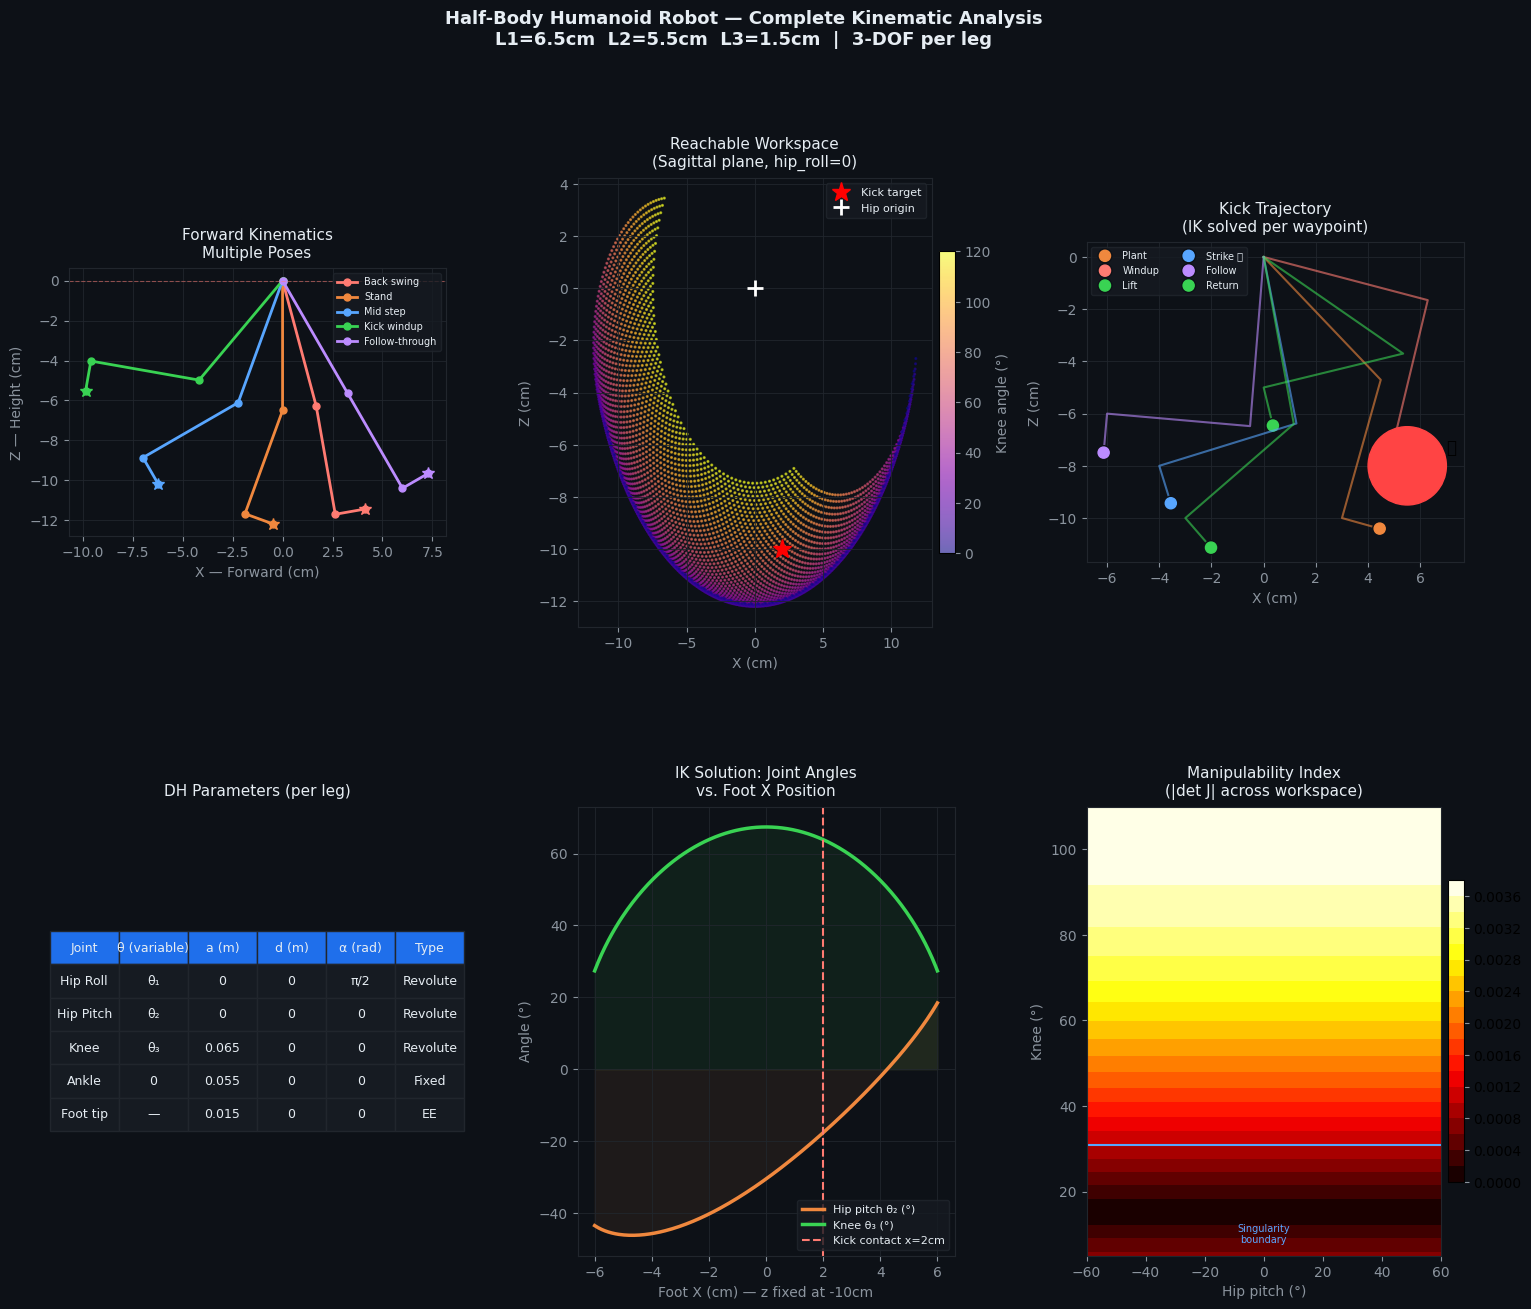

✅ Kinematics diagram saved: kinematics_diagram.png


In [ ]:
# ============================================================
#  KINEMATIC DIAGRAM  —  saved as kinematics_diagram.png
# ============================================================

fig = plt.figure(figsize=(18, 14), facecolor='#0d1117')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

DARK  = '#0d1117'
GRID  = '#21262d'
BLUE  = '#58a6ff'
CYAN  = '#39d353'
ORANGE= '#f0883e'
RED   = '#ff7b72'
WHITE = '#e6edf3'
DIM   = '#8b949e'


# ------------------------------------------------------------------
# PANEL A — FK skeleton at multiple poses
# ------------------------------------------------------------------
ax_a = fig.add_subplot(gs[0, 0], facecolor=DARK)
ax_a.set_title('Forward Kinematics\nMultiple Poses', color=WHITE, fontsize=11, pad=8)

poses = [
    (0, np.radians(-15), np.radians(5),  '#ff7b72', 'Back swing'),
    (0, np.radians(0),   np.radians(20), '#f0883e', 'Stand'),
    (0, np.radians(20),  np.radians(40), '#58a6ff', 'Mid step'),
    (0, np.radians(40),  np.radians(60), '#39d353', 'Kick windup'),
    (0, np.radians(-30), np.radians(0),  '#bc8cff', 'Follow-through'),
]

for (roll, pitch, knee, col, label) in poses:
    ph, pk, pa, pf = forward_kinematics(roll, pitch, knee)
    pts = np.array([ph, pk, pa, pf]) * 100
    ax_a.plot(pts[:,0], pts[:,2], '-o', color=col, lw=2, ms=5, label=label)
    ax_a.plot(pts[-1,0], pts[-1,2], '*', color=col, ms=9)

ax_a.set_xlabel('X — Forward (cm)', color=DIM)
ax_a.set_ylabel('Z — Height (cm)', color=DIM)
ax_a.tick_params(colors=DIM)
ax_a.set_facecolor(DARK)
for sp in ax_a.spines.values(): sp.set_color(GRID)
ax_a.grid(True, color=GRID, lw=0.6)
ax_a.legend(fontsize=7, facecolor='#161b22', edgecolor=GRID, labelcolor=WHITE)
ax_a.axhline(0, color=RED, lw=0.8, ls='--', alpha=0.5)
ax_a.set_aspect('equal')


# ------------------------------------------------------------------
# PANEL B — IK workspace
# ------------------------------------------------------------------
ax_b = fig.add_subplot(gs[0, 1], facecolor=DARK)
ax_b.set_title('Reachable Workspace\n(Sagittal plane, hip_roll=0)', color=WHITE, fontsize=11, pad=8)

thetas_hip  = np.linspace(-np.radians(70), np.radians(70),  60)
thetas_knee = np.linspace(0,               np.radians(120), 60)
xs, zs, ks = [], [], []
for h in thetas_hip:
    for k in thetas_knee:
        _,_,_,pf = forward_kinematics(0, h, k)
        xs.append(pf[0]*100); zs.append(pf[2]*100); ks.append(np.degrees(k))

sc = ax_b.scatter(xs, zs, c=ks, cmap='plasma', s=1.5, alpha=0.6)
cbar = plt.colorbar(sc, ax=ax_b, fraction=0.04, pad=0.02)
cbar.set_label('Knee angle (°)', color=DIM)
cbar.ax.yaxis.set_tick_params(color=DIM)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=DIM)

# Mark kick target
ax_b.plot(2, -10, 'r*', ms=14, label='Kick target')
ax_b.plot(0,  0,  'w+', ms=12, mew=2, label='Hip origin')
ax_b.set_xlabel('X (cm)', color=DIM)
ax_b.set_ylabel('Z (cm)', color=DIM)
ax_b.tick_params(colors=DIM)
for sp in ax_b.spines.values(): sp.set_color(GRID)
ax_b.grid(True, color=GRID, lw=0.6)
ax_b.legend(fontsize=8, facecolor='#161b22', edgecolor=GRID, labelcolor=WHITE)
ax_b.set_facecolor(DARK)


# ------------------------------------------------------------------
# PANEL C — Kick trajectory IK
# ------------------------------------------------------------------
ax_c = fig.add_subplot(gs[0, 2], facecolor=DARK)
ax_c.set_title('Kick Trajectory\n(IK solved per waypoint)', color=WHITE, fontsize=11, pad=8)

# Define kick trajectory waypoints in (x, z) space
kick_wpts = [
    (-0.03, -0.10),   # 1. plant stance
    (-0.05, -0.07),   # 2. windup back
    ( 0.00, -0.05),   # 3. lift phase
    ( 0.04, -0.08),   # 4. strike (ball contact)
    ( 0.06, -0.06),   # 5. follow-through
    ( 0.03, -0.10),   # 6. return
]

colors_wpt = [ORANGE, RED, CYAN, BLUE, '#bc8cff', CYAN]
labels_wpt = ['Plant','Windup','Lift','Strike ⚽','Follow','Return']

prev_pts = None
for i,(wpt,col,lbl) in enumerate(zip(kick_wpts, colors_wpt, labels_wpt)):
    h, k = ik_2d(*wpt)
    ph, pk, pa, pf = forward_kinematics(0, h, k)
    pts = np.array([ph, pk, pa, pf]) * 100
    ax_c.plot(pts[:,0], pts[:,2], '-', color=col, lw=1.5, alpha=0.6)
    ax_c.plot(pts[-1,0], pts[-1,2], 'o', color=col, ms=8, label=lbl,
              path_effects=[pe.withStroke(linewidth=3, foreground=DARK)])

# Ball position
ball_x, ball_z = kick_wpts[3][0]*100, kick_wpts[3][1]*100
ball_circ = Circle((ball_x+1.5, ball_z), 1.5, color='#ff4444', zorder=10)
ax_c.add_patch(ball_circ)
ax_c.text(ball_x+3, ball_z+0.5, '⚽', fontsize=12)

ax_c.set_xlabel('X (cm)', color=DIM)
ax_c.set_ylabel('Z (cm)', color=DIM)
ax_c.tick_params(colors=DIM)
for sp in ax_c.spines.values(): sp.set_color(GRID)
ax_c.grid(True, color=GRID, lw=0.6)
ax_c.legend(fontsize=7, facecolor='#161b22', edgecolor=GRID, labelcolor=WHITE, ncol=2)
ax_c.set_facecolor(DARK)
ax_c.set_aspect('equal')


# ------------------------------------------------------------------
# PANEL D — DH parameter table
# ------------------------------------------------------------------
ax_d = fig.add_subplot(gs[1, 0], facecolor=DARK)
ax_d.set_facecolor(DARK)
ax_d.set_title('DH Parameters (per leg)', color=WHITE, fontsize=11, pad=8)
ax_d.axis('off')

dh_data = [
    ['Joint', 'θ (variable)', 'a (m)', 'd (m)', 'α (rad)', 'Type'],
    ['Hip Roll',  'θ₁',  '0',     '0',     'π/2',  'Revolute'],
    ['Hip Pitch', 'θ₂',  '0',     '0',     '0',    'Revolute'],
    ['Knee',      'θ₃',  str(L1), '0',     '0',    'Revolute'],
    ['Ankle',     '0',   str(L2), '0',     '0',    'Fixed'],
    ['Foot tip',  '—',   str(L3), '0',     '0',    'EE'],
]

col_colors = [[BLUE]*6] + [[DARK]*6]*5
row_colors = [[DARK]*6]*6
cell_colors = [['#161b22']*6]*6
cell_colors[0] = ['#1f6feb']*6

tbl = ax_d.table(
    cellText=dh_data[1:],
    colLabels=dh_data[0],
    cellLoc='center', loc='center',
    cellColours=[['#161b22']*6]*5,
    colColours=['#1f6feb']*6
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 2.0)
for (r,c), cell in tbl.get_celld().items():
    cell.set_text_props(color=WHITE)
    cell.set_edgecolor(GRID)


# ------------------------------------------------------------------
# PANEL E — IK joint angles vs foot-x
# ------------------------------------------------------------------
ax_e = fig.add_subplot(gs[1, 1], facecolor=DARK)
ax_e.set_title('IK Solution: Joint Angles\nvs. Foot X Position', color=WHITE, fontsize=11, pad=8)

x_range = np.linspace(-0.06, 0.06, 200)
hip_angles, knee_angles = [], []
for x in x_range:
    h, k = ik_2d(x, -0.100)
    hip_angles.append(np.degrees(h))
    knee_angles.append(np.degrees(k))

ax_e.plot(x_range*100, hip_angles,  color=ORANGE, lw=2.5, label='Hip pitch θ₂ (°)')
ax_e.plot(x_range*100, knee_angles, color=CYAN,   lw=2.5, label='Knee θ₃ (°)')
ax_e.axvline(2, color=RED, ls='--', lw=1.5, label='Kick contact x=2cm')
ax_e.fill_between(x_range*100, hip_angles, alpha=0.08, color=ORANGE)
ax_e.fill_between(x_range*100, knee_angles, alpha=0.08, color=CYAN)
ax_e.set_xlabel('Foot X (cm) — z fixed at -10cm', color=DIM)
ax_e.set_ylabel('Angle (°)', color=DIM)
ax_e.tick_params(colors=DIM)
for sp in ax_e.spines.values(): sp.set_color(GRID)
ax_e.grid(True, color=GRID, lw=0.6)
ax_e.legend(fontsize=8, facecolor='#161b22', edgecolor=GRID, labelcolor=WHITE)
ax_e.set_facecolor(DARK)


# ------------------------------------------------------------------
# PANEL F — Jacobian determinant (manipulability)
# ------------------------------------------------------------------
ax_f = fig.add_subplot(gs[1, 2], facecolor=DARK)
ax_f.set_title('Manipulability Index\n(|det J| across workspace)', color=WHITE, fontsize=11, pad=8)

H = np.linspace(-np.radians(60), np.radians(60), 60)
K = np.linspace(np.radians(5),   np.radians(110), 60)
HH, KK = np.meshgrid(H, K)
MANIP = np.zeros_like(HH)

for i in range(HH.shape[0]):
    for j in range(HH.shape[1]):
        h_, k_ = HH[i,j], KK[i,j]
        # 2x2 Jacobian (dx/dθ, dz/dθ) for hip and knee
        eps = 1e-5
        _,_,_,p0 = forward_kinematics(0, h_, k_)
        _,_,_,ph = forward_kinematics(0, h_+eps, k_)
        _,_,_,pk = forward_kinematics(0, h_, k_+eps)
        J = np.array([
            [(ph[0]-p0[0])/eps, (pk[0]-p0[0])/eps],
            [(ph[2]-p0[2])/eps, (pk[2]-p0[2])/eps]
        ])
        MANIP[i,j] = abs(np.linalg.det(J))

cf = ax_f.contourf(np.degrees(HH), np.degrees(KK), MANIP, levels=20, cmap='hot')
plt.colorbar(cf, ax=ax_f, fraction=0.04, pad=0.02).ax.yaxis.set_tick_params(color=DIM)
# Mark singularity region
ax_f.contour(np.degrees(HH), np.degrees(KK), MANIP, levels=[0.001], colors=[BLUE], linewidths=1.5)
ax_f.set_xlabel('Hip pitch (°)', color=DIM)
ax_f.set_ylabel('Knee (°)', color=DIM)
ax_f.tick_params(colors=DIM)
for sp in ax_f.spines.values(): sp.set_color(GRID)
ax_f.set_facecolor(DARK)
ax_f.text(0, 8, 'Singularity\nboundary', color=BLUE, fontsize=7, ha='center')


fig.suptitle('Half-Body Humanoid Robot — Complete Kinematic Analysis\nL1=6.5cm  L2=5.5cm  L3=1.5cm  |  3-DOF per leg',
             color=WHITE, fontsize=13, fontweight='bold', y=1.00)

plt.savefig('kinematics_diagram.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print('✅ Kinematics diagram saved: kinematics_diagram.png')

## ⚙️ Step 5 — PyBullet Physics World Setup

In [ ]:
# ============================================================
#  PYBULLET — headless physics world
# ============================================================
if p.isConnected():
    p.disconnect()

physicsClient = p.connect(p.DIRECT)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0, 0, -9.81)
p.setTimeStep(TIME_STEP)
p.setRealTimeSimulation(0)

# Ground plane
plane_id = p.loadURDF('plane.urdf')

# Change plane color to green (grass)
p.changeVisualShape(plane_id, -1, rgbaColor=[0.15, 0.55, 0.15, 1.0])

# Robot — start at x=0 facing +x
robot_id = p.loadURDF('half_humanoid.urdf',
                       basePosition=[0.0, 0.0, 0.185],
                       baseOrientation=p.getQuaternionFromEuler([0,0,0]))

# =====================
# RED BALL — placed 20cm ahead of robot
# =====================
BALL_RADIUS   = 0.022
BALL_START_X  = 0.20   # 20cm in front of robot

ball_col = p.createCollisionShape(p.GEOM_SPHERE, radius=BALL_RADIUS)
ball_vis = p.createVisualShape(p.GEOM_SPHERE, radius=BALL_RADIUS,
                                rgbaColor=[0.95, 0.10, 0.10, 1.0])  # RED
ball_id  = p.createMultiBody(
    baseMass=0.043,
    baseCollisionShapeIndex=ball_col,
    baseVisualShapeIndex=ball_vis,
    basePosition=[BALL_START_X, 0.0, BALL_RADIUS]
)

# Ball physics — bouncy and low friction
p.changeDynamics(ball_id, -1,
    restitution=0.72,
    lateralFriction=0.4,
    rollingFriction=0.002,
    linearDamping=0.01,
    angularDamping=0.05
)

# =====================
# JOINT MAP
# =====================
JOINT_MAP = {}
for i in range(p.getNumJoints(robot_id)):
    info = p.getJointInfo(robot_id, i)
    name = info[1].decode('utf-8')
    if info[2] != p.JOINT_FIXED:
        JOINT_MAP[name] = i

print(f'✅ World ready! Robot ID={robot_id}, Ball ID={ball_id}')
print(f'   Active joints: {list(JOINT_MAP.keys())}')

✅ World ready! Robot ID=1, Ball ID=2
   Active joints: ['left_hip_roll', 'left_hip_pitch', 'left_knee', 'right_hip_roll', 'right_hip_pitch', 'right_knee']


## 🕹️ Step 6 — Controller & Camera

In [ ]:
# ============================================================
#  SERVO CONTROLLER
# ============================================================
SERVO_FORCE = 0.20
SERVO_SPEED = 12.0

def set_joint(name, angle_rad):
    if name not in JOINT_MAP: return
    p.setJointMotorControl2(
        robot_id, JOINT_MAP[name],
        controlMode=p.POSITION_CONTROL,
        targetPosition=float(angle_rad),
        force=SERVO_FORCE, maxVelocity=SERVO_SPEED
    )

def set_pose(lhr=0, lhp=0, lk=0, rhr=0, rhp=0, rk=0):
    set_joint('left_hip_roll',   lhr)
    set_joint('left_hip_pitch',  lhp)
    set_joint('left_knee',       lk)
    set_joint('right_hip_roll',  rhr)
    set_joint('right_hip_pitch', rhp)
    set_joint('right_knee',      rk)

def step_n(n):
    for _ in range(n):
        p.stepSimulation()


# ============================================================
#  CAMERA RENDERER
# ============================================================
def render(yaw=40, pitch=-22, dist=0.55, target=None):
    """Render 640x480 RGB frame."""
    if target is None:
        pos, _ = p.getBasePositionAndOrientation(robot_id)
        target = [pos[0], pos[1], 0.09]
    W, H = 640, 480
    vm = p.computeViewMatrixFromYawPitchRoll(
        target, dist, yaw, pitch, 0, 2)
    pm = p.computeProjectionMatrixFOV(60, W/H, 0.01, 10.0)
    _, _, rgb, _, _ = p.getCameraImage(W, H, vm, pm,
                                        renderer=p.ER_TINY_RENDERER)
    return np.array(rgb, dtype=np.uint8).reshape(H, W, 4)[:,:,:3]

print('✅ Controller and camera ready!')

# Settle the robot
set_pose(lhp=np.radians(12), lk=np.radians(24), rhp=np.radians(12), rk=np.radians(24))
step_n(300)
print('   Robot settled into rest pose.')

✅ Controller and camera ready!
   Robot settled into rest pose.


## 🔴 Step 7 — HSV Ball Detector (OpenCV)

✅ HSV Detector ready!
   Test detection: detected=True, centroid=(285,340), radius=22px


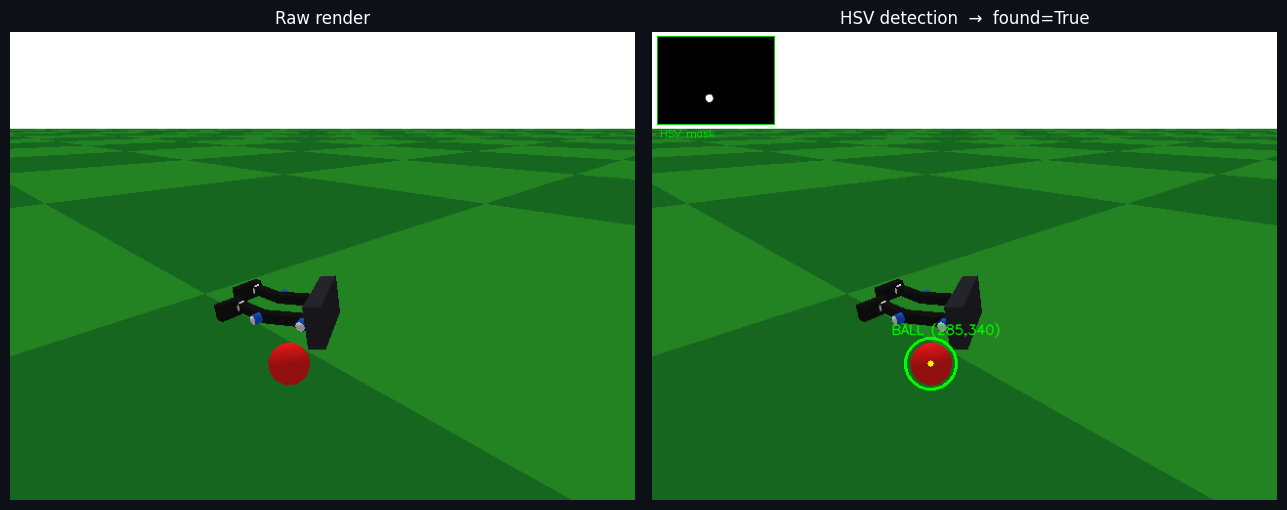

In [ ]:
# ============================================================
#  HSV BALL DETECTOR
#  Detects the RED ball in rendered RGB frames.
#  Red in HSV wraps around 0°/360°, so we use two masks.
# ============================================================

# Red HSV ranges (H is 0-179 in OpenCV)
HSV_RED_LO1 = np.array([0,   120, 100])
HSV_RED_HI1 = np.array([10,  255, 255])
HSV_RED_LO2 = np.array([165, 120, 100])
HSV_RED_HI2 = np.array([179, 255, 255])

MIN_BALL_AREA = 80   # pixels² — ignore noise

def detect_ball(frame_rgb):
    """
    Detect red ball in an RGB frame using HSV thresholding.
    Returns:
        detected (bool)
        cx, cy  — pixel centroid
        radius  — estimated pixel radius
        annotated_frame — frame with detection overlay drawn
    """
    hsv = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2HSV)

    # Two masks to catch both red hue regions
    mask1 = cv2.inRange(hsv, HSV_RED_LO1, HSV_RED_HI1)
    mask2 = cv2.inRange(hsv, HSV_RED_LO2, HSV_RED_HI2)
    mask  = cv2.bitwise_or(mask1, mask2)

    # Morphological cleanup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    annotated = frame_rgb.copy()

    if not contours:
        return False, 0, 0, 0, annotated

    # Largest contour = ball
    c = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(c)

    if area < MIN_BALL_AREA:
        return False, 0, 0, 0, annotated

    (cx, cy), radius = cv2.minEnclosingCircle(c)
    cx, cy, radius = int(cx), int(cy), int(radius)

    # Draw detections (convert RGB→BGR for cv2, then back)
    bgr = cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR)
    cv2.circle(bgr, (cx, cy), radius+4, (0,255,0), 2)          # green circle
    cv2.circle(bgr, (cx, cy), 3,        (0,255,255), -1)        # cyan centre
    cv2.putText(bgr, f'BALL ({cx},{cy})', (cx-40, cy-radius-8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,255,0), 1, cv2.LINE_AA)
    # Draw HSV mask inset (top-left corner)
    mask_small = cv2.resize(cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR), (120,90))
    bgr[5:95, 5:125] = mask_small
    cv2.rectangle(bgr, (5,5), (125,95), (0,200,0), 1)
    cv2.putText(bgr, 'HSV mask', (8,108),
                cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,220,0), 1)
    annotated = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    return True, cx, cy, radius, annotated


# Quick test
test_frame = render(yaw=45, pitch=-20, dist=0.50)
det, cx, cy, r, ann = detect_ball(test_frame)
print(f'✅ HSV Detector ready!')
print(f'   Test detection: detected={det}, centroid=({cx},{cy}), radius={r}px')

fig, axes = plt.subplots(1, 2, figsize=(13,5), facecolor='#0d1117')
axes[0].imshow(test_frame)
axes[0].set_title('Raw render', color='white')
axes[0].axis('off')
axes[1].imshow(ann)
axes[1].set_title(f'HSV detection  →  found={det}', color='white')
axes[1].axis('off')
fig.patch.set_facecolor('#0d1117')
plt.tight_layout()
plt.show()

## 🚶 Step 8 — Walking Gait + Approach + Kick Sequence

In [ ]:
# ============================================================
#  FULL SEQUENCE:
#  Phase 0: Walk toward ball (3 cycles)
#  Phase 1: Detect ball with HSV, slow approach
#  Phase 2: Wind-up
#  Phase 3: Kick strike
#  Phase 4: Follow-through + ball flies
#  Phase 5: Return to balance
# ============================================================

frames      = []   # all rendered frames
frame_labels= []   # phase label per frame
joint_log   = {'t':[], 'lhp':[], 'lk':[], 'rhp':[], 'rk':[]}
ball_traj   = []   # ball world positions
detection_log = [] # (frame_idx, cx, cy, radius)

RENDER_EVERY = 12  # physics steps between renders
step_counter = [0]

def sim_step(pose_dict, n_physics=1, phase=''):
    """Apply pose, step physics n times, capture frames periodically."""
    set_pose(**pose_dict)
    for _ in range(n_physics):
        p.stepSimulation()
        step_counter[0] += 1

        if step_counter[0] % RENDER_EVERY == 0:
            # Render from slightly rotating camera for dynamic feel
            t_norm = step_counter[0] / 100.0
            yaw = 40 + 15*np.sin(t_norm*0.4)
            fr = render(yaw=yaw, pitch=-20, dist=0.52)

            # HSV detection on every frame
            det, cx, cy, rad, ann_fr = detect_ball(fr)
            if det:
                detection_log.append((len(frames), cx, cy, rad))
                frame = ann_fr
            else:
                frame = fr

            # Add phase label overlay
            bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
            cv2.rectangle(bgr, (0, 440), (640, 480), (0,0,0), -1)
            cv2.putText(bgr, phase, (10, 468),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255,220,60), 2)
            ball_pos, _ = p.getBasePositionAndOrientation(ball_id)
            cv2.putText(bgr, f'Ball: ({ball_pos[0]*100:.1f}, {ball_pos[2]*100:.1f}) cm',
                        (380, 468), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (100,255,100), 1)
            frames.append(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
            frame_labels.append(phase)

        # Log joints every 10 steps
        if step_counter[0] % 10 == 0:
            js = {}
            for name, idx in JOINT_MAP.items():
                js[name] = p.getJointState(robot_id, idx)[0]
            joint_log['t'].append(step_counter[0] * TIME_STEP)
            joint_log['lhp'].append(np.degrees(js.get('left_hip_pitch', 0)))
            joint_log['lk'].append(np.degrees(js.get('left_knee', 0)))
            joint_log['rhp'].append(np.degrees(js.get('right_hip_pitch', 0)))
            joint_log['rk'].append(np.degrees(js.get('right_knee', 0)))
            bp, _ = p.getBasePositionAndOrientation(ball_id)
            ball_traj.append(list(bp))


# ============================================================
# PHASE 0 — Walking gait (3 full cycles, 1.5 Hz)
# ============================================================
print('▶ Phase 0: Walking...')
omega = 2*np.pi*1.4
t_walk = 0.0
n_walk_steps = int(3.0 / TIME_STEP)   # 3 seconds

for i in range(n_walk_steps):
    t_walk += TIME_STEP
    phL, phR = omega*t_walk, omega*t_walk + np.pi

    lhp =  np.radians(18)*np.sin(phL)
    rhp =  np.radians(18)*np.sin(phR)
    lk  =  np.radians(14) + np.radians(22)*max(np.sin(phL+0.3), 0)
    rk  =  np.radians(14) + np.radians(22)*max(np.sin(phR+0.3), 0)
    lhr =  np.radians(4)*np.sin(phL+np.pi/2)
    rhr =  np.radians(4)*np.sin(phR+np.pi/2)

    sim_step({'lhr':lhr,'lhp':lhp,'lk':lk,'rhr':rhr,'rhp':rhp,'rk':rk},
             n_physics=1, phase='Phase 0: Walking toward ball')

print(f'   Done. Frames so far: {len(frames)}')


# ============================================================
# PHASE 1 — Slow approach + ball detection
# ============================================================
print('▶ Phase 1: Slow approach + HSV detection...')
t_app = 0.0
n_app = int(1.5 / TIME_STEP)

for i in range(n_app):
    t_app += TIME_STEP
    phL, phR = omega*0.6*t_app, omega*0.6*t_app + np.pi
    lhp = np.radians(12)*np.sin(phL)
    rhp = np.radians(12)*np.sin(phR)
    lk  = np.radians(12) + np.radians(14)*max(np.sin(phL+0.3), 0)
    rk  = np.radians(12) + np.radians(14)*max(np.sin(phR+0.3), 0)
    sim_step({'lhp':lhp,'lk':lk,'rhp':rhp,'rk':rk},
             n_physics=1, phase='Phase 1: HSV ball detection')

print(f'   Done. Frames: {len(frames)}  |  Ball detections: {len(detection_log)}')


# ============================================================
# PHASE 2 — Balance on right, wind-up left leg
# ============================================================
print('▶ Phase 2: Wind-up...')
for t in np.linspace(0, 1.2, int(1.2/TIME_STEP)):
    prog = t/1.2   # 0→1
    lhp_target = np.radians(-35) * prog   # swing back
    lk_target  = np.radians(60)  * prog   # bend knee
    rhp_stance = np.radians(8)
    rk_stance  = np.radians(18)
    sim_step({'lhp':lhp_target,'lk':lk_target,'rhp':rhp_stance,'rk':rk_stance},
             n_physics=1, phase='Phase 2: Kick wind-up')

print(f'   Done. Frames: {len(frames)}')


# ============================================================
# PHASE 3 — STRIKE!  Fast forward snap
# ============================================================
print('▶ Phase 3: KICK STRIKE!')
n_kick = int(0.25 / TIME_STEP)   # very fast

# Set very high velocity for kick joint
p.setJointMotorControl2(robot_id, JOINT_MAP['left_hip_pitch'],
    controlMode=p.POSITION_CONTROL,
    targetPosition=np.radians(55),   # full forward
    force=0.35, maxVelocity=20.0)    # fast!
p.setJointMotorControl2(robot_id, JOINT_MAP['left_knee'],
    controlMode=p.POSITION_CONTROL,
    targetPosition=np.radians(5),    # extend fast
    force=0.30, maxVelocity=20.0)

for i in range(n_kick):
    p.stepSimulation()
    step_counter[0] += 1
    if step_counter[0] % RENDER_EVERY == 0:
        fr = render(yaw=55, pitch=-18, dist=0.48)
        det, cx, cy, rad, ann = detect_ball(fr)
        frame = ann if det else fr
        bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        cv2.rectangle(bgr, (0,440),(640,480),(150,0,0),-1)
        cv2.putText(bgr,'⚡ Phase 3: KICK! ⚡',(10,468),
                    cv2.FONT_HERSHEY_SIMPLEX,0.70,(50,200,255),2)
        frames.append(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
        frame_labels.append('Phase 3: KICK!')

print(f'   Kick done. Frames: {len(frames)}')


# ============================================================
# PHASE 4 — Follow-through + ball flies (2 seconds)
# ============================================================
print('▶ Phase 4: Follow-through, ball flies...')
for t in np.linspace(0, 2.0, int(2.0/TIME_STEP)):
    prog = min(t/0.6, 1.0)
    lhp = np.radians(55) * (1-prog) + np.radians(10)*prog   # settle back
    lk  = np.radians(5)  * (1-prog) + np.radians(25)*prog
    sim_step({'lhp':lhp,'lk':lk,'rhp':np.radians(8),'rk':np.radians(18)},
             n_physics=1, phase='Phase 4: Follow-through & ball flies')

print(f'   Done. Frames: {len(frames)}')


# ============================================================
# PHASE 5 — Return to rest (1.5 seconds)
# ============================================================
print('▶ Phase 5: Returning to balance...')
for t in np.linspace(0, 1.5, int(1.5/TIME_STEP)):
    sim_step({'lhp':np.radians(12),'lk':np.radians(22),
              'rhp':np.radians(12),'rk':np.radians(22)},
             n_physics=1, phase='Phase 5: Return to balance')

print(f'\n✅ Simulation complete!')
print(f'   Total frames: {len(frames)}')
print(f'   Total ball detections: {len(detection_log)}')
ball_final, _ = p.getBasePositionAndOrientation(ball_id)
print(f'   Ball final position: x={ball_final[0]*100:.1f}cm  z={ball_final[2]*100:.1f}cm')

▶ Phase 0: Walking...
   Done. Frames so far: 60
▶ Phase 1: Slow approach + HSV detection...
   Done. Frames: 90  |  Ball detections: 90
▶ Phase 2: Wind-up...
   Done. Frames: 114
▶ Phase 3: KICK STRIKE!
   Kick done. Frames: 119
▶ Phase 4: Follow-through, ball flies...
   Done. Frames: 159
▶ Phase 5: Returning to balance...

✅ Simulation complete!
   Total frames: 189
   Total ball detections: 184
   Ball final position: x=26.6cm  z=2.2cm


## 🎬 Step 9 — Export Walking GIF (long version)

In [ ]:
# ============================================================
#  EXPORT GIF  —  full sequence, all phases
# ============================================================
gif_path = 'robot_kick_sequence.gif'

# Convert to PIL, resize slightly to keep file reasonable
pil_frames = []
for fr in frames:
    img = PILImage.fromarray(fr)
    # Resize to 480x360 to balance quality vs file size
    img = img.resize((480, 360), PILImage.LANCZOS)
    pil_frames.append(img)

# Frame duration: 40ms ≈ 25fps (RENDER_EVERY=12 @ 240Hz → every 0.05s)
FRAME_MS = int(1000 * TIME_STEP * RENDER_EVERY)  # ~50ms

pil_frames[0].save(
    gif_path,
    save_all=True,
    append_images=pil_frames[1:],
    optimize=True,
    duration=FRAME_MS,
    loop=0
)

import os
size_mb = os.path.getsize(gif_path) / 1e6
duration_s = len(pil_frames) * FRAME_MS / 1000
print(f'✅ GIF saved: {gif_path}')
print(f'   Frames: {len(pil_frames)}')
print(f'   Duration: {duration_s:.1f} seconds')
print(f'   File size: {size_mb:.1f} MB')

display(IPImage(filename=gif_path, width=480))

Output hidden; open in https://colab.research.google.com to view.

## 📊 Step 10 — Joint Trajectories + Ball Trajectory

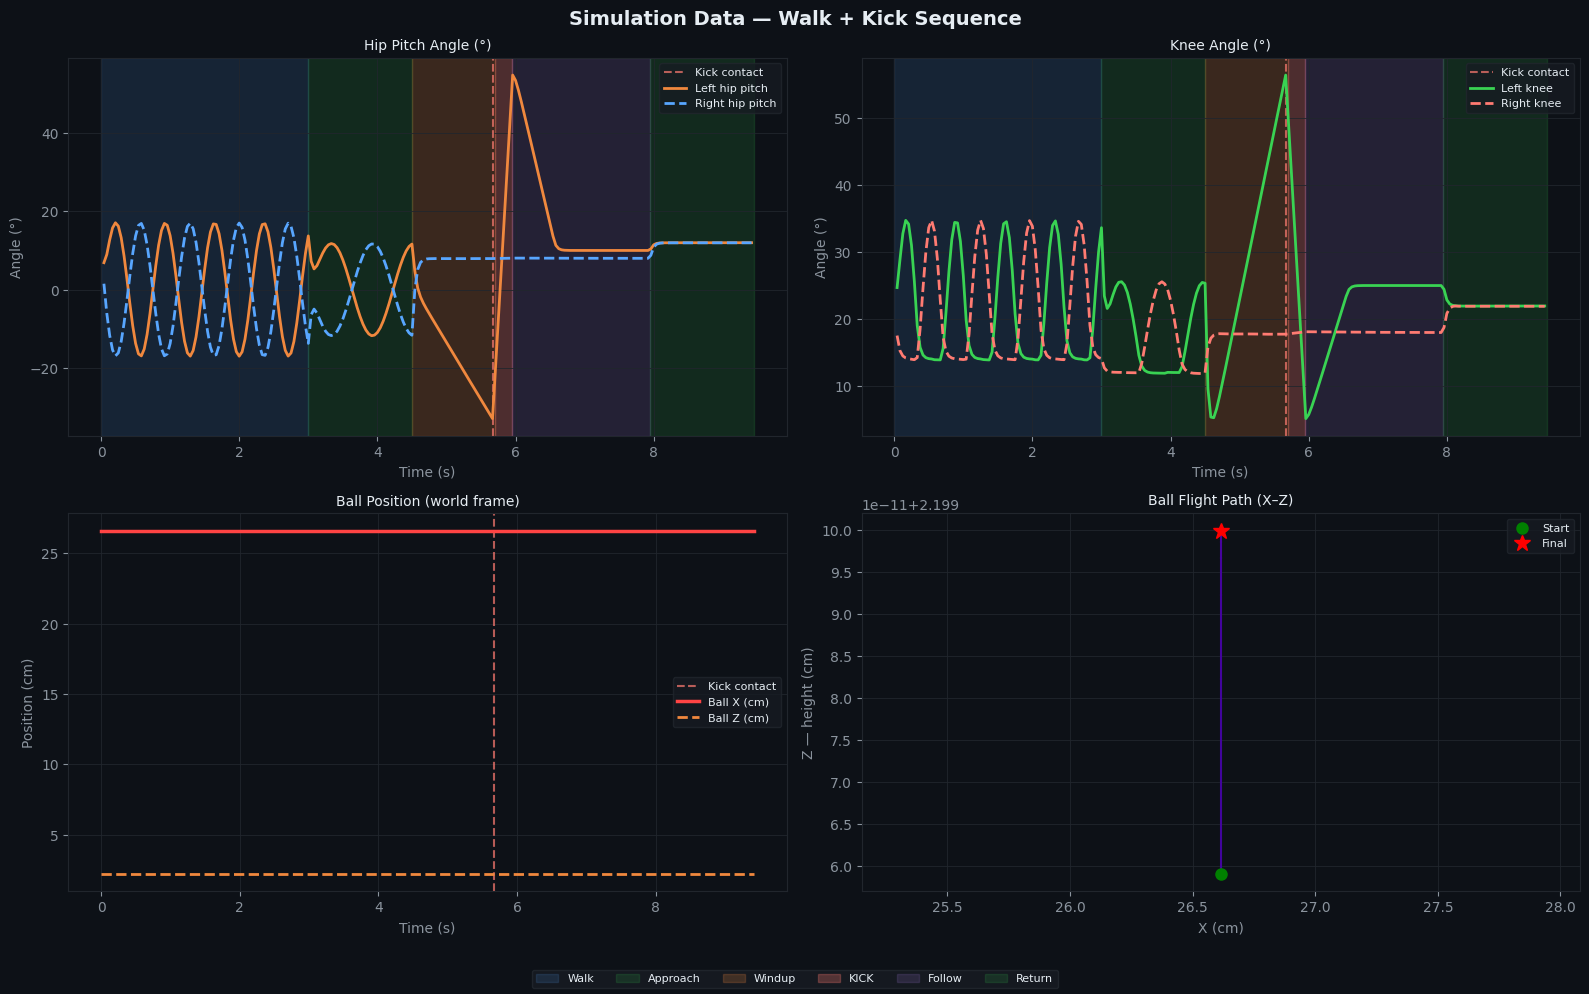

✅ Trajectory plots saved: joint_ball_trajectories.png


In [ ]:
# ============================================================
#  JOINT + BALL TRAJECTORY PLOTS
# ============================================================
DARK  = '#0d1117'
GRID  = '#21262d'
BLUE  = '#58a6ff'
CYAN  = '#39d353'
ORANGE= '#f0883e'
RED   = '#ff7b72'
WHITE = '#e6edf3'
DIM   = '#8b949e'

fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor=DARK)
fig.suptitle('Simulation Data — Walk + Kick Sequence', color=WHITE, fontsize=14, fontweight='bold')

T = np.array(joint_log['t'])

# Find kick moment (peak |left_hip_pitch| rate)
lhp_arr = np.array(joint_log['lhp'])
kick_idx = np.argmax(np.abs(np.diff(lhp_arr)))
kick_t   = T[kick_idx] if kick_idx < len(T) else T[-1]

def style_ax(ax, title):
    ax.set_facecolor(DARK)
    ax.set_title(title, color=WHITE, fontsize=10)
    ax.tick_params(colors=DIM)
    ax.xaxis.label.set_color(DIM)
    ax.yaxis.label.set_color(DIM)
    for sp in ax.spines.values(): sp.set_color(GRID)
    ax.grid(True, color=GRID, lw=0.6)
    ax.axvline(kick_t, color=RED, ls='--', lw=1.5, alpha=0.7, label='Kick contact')

# Phase background shading helper
phase_times = [
    (0,   3.0,  '#58a6ff22', 'Walk'),
    (3.0, 4.5,  '#39d35322', 'Approach'),
    (4.5, 5.7,  '#f0883e33', 'Windup'),
    (5.7, 5.95, '#ff7b7244', 'KICK'),
    (5.95,7.95, '#bc8cff22', 'Follow'),
    (7.95,9.45, '#39d35322', 'Return'),
]

def add_phases(ax):
    for (t0, t1, col, lbl) in phase_times:
        ax.axvspan(t0, t1, color=col, zorder=0)


# Panel 1 — Hip pitch
ax = axes[0,0]
style_ax(ax, 'Hip Pitch Angle (°)')
add_phases(ax)
ax.plot(T, lhp_arr, color=ORANGE, lw=2, label='Left hip pitch')
ax.plot(T, joint_log['rhp'], color=BLUE, lw=2, ls='--', label='Right hip pitch')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Angle (°)')
ax.legend(fontsize=8, facecolor='#161b22', edgecolor=GRID, labelcolor=WHITE)

# Panel 2 — Knee angle
ax = axes[0,1]
style_ax(ax, 'Knee Angle (°)')
add_phases(ax)
ax.plot(T, joint_log['lk'], color=CYAN, lw=2, label='Left knee')
ax.plot(T, joint_log['rk'], color=RED,  lw=2, ls='--', label='Right knee')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Angle (°)')
ax.legend(fontsize=8, facecolor='#161b22', edgecolor=GRID, labelcolor=WHITE)

# Panel 3 — Ball X trajectory
ax = axes[1,0]
style_ax(ax, 'Ball Position (world frame)')
bt = np.array(ball_traj)
t_ball = np.linspace(0, T[-1], len(bt))
ax.plot(t_ball, bt[:,0]*100, color='#ff4444', lw=2.5, label='Ball X (cm)')
ax.plot(t_ball, bt[:,2]*100, color=ORANGE,    lw=2,   label='Ball Z (cm)', ls='--')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Position (cm)')
ax.legend(fontsize=8, facecolor='#161b22', edgecolor=GRID, labelcolor=WHITE)

# Panel 4 — Ball 2D trajectory
ax = axes[1,1]
ax.set_facecolor(DARK)
ax.set_title('Ball Flight Path (X–Z)', color=WHITE, fontsize=10)
ax.tick_params(colors=DIM)
for sp in ax.spines.values(): sp.set_color(GRID)
ax.grid(True, color=GRID, lw=0.6)

# Color by time
n_bt = len(bt)
colors_traj = plt.cm.plasma(np.linspace(0.1, 0.9, n_bt))
for i in range(n_bt-1):
    ax.plot(bt[i:i+2,0]*100, bt[i:i+2,2]*100, '-', color=colors_traj[i], lw=1.5)
ax.plot(bt[0,0]*100,  bt[0,2]*100,  'go', ms=8, label='Start', zorder=10)
ax.plot(bt[-1,0]*100, bt[-1,2]*100, 'r*', ms=12,label='Final', zorder=10)
ax.set_xlabel('X (cm)', color=DIM); ax.set_ylabel('Z — height (cm)', color=DIM)
ax.legend(fontsize=8, facecolor='#161b22', edgecolor=GRID, labelcolor=WHITE)

# Phase legend
for ax in axes.flat:
    handles = [mpatches.Patch(color=c, label=l) for (_,_,c,l) in phase_times]

fig.legend(handles, [l for *_,l in phase_times],
           loc='lower center', ncol=6, fontsize=8,
           facecolor='#161b22', edgecolor=GRID, labelcolor=WHITE, framealpha=0.9)

plt.tight_layout(rect=[0,0.04,1,1])
plt.savefig('joint_ball_trajectories.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print('✅ Trajectory plots saved: joint_ball_trajectories.png')

## 🎞️ Step 11 — Phase Grid: Key Frames

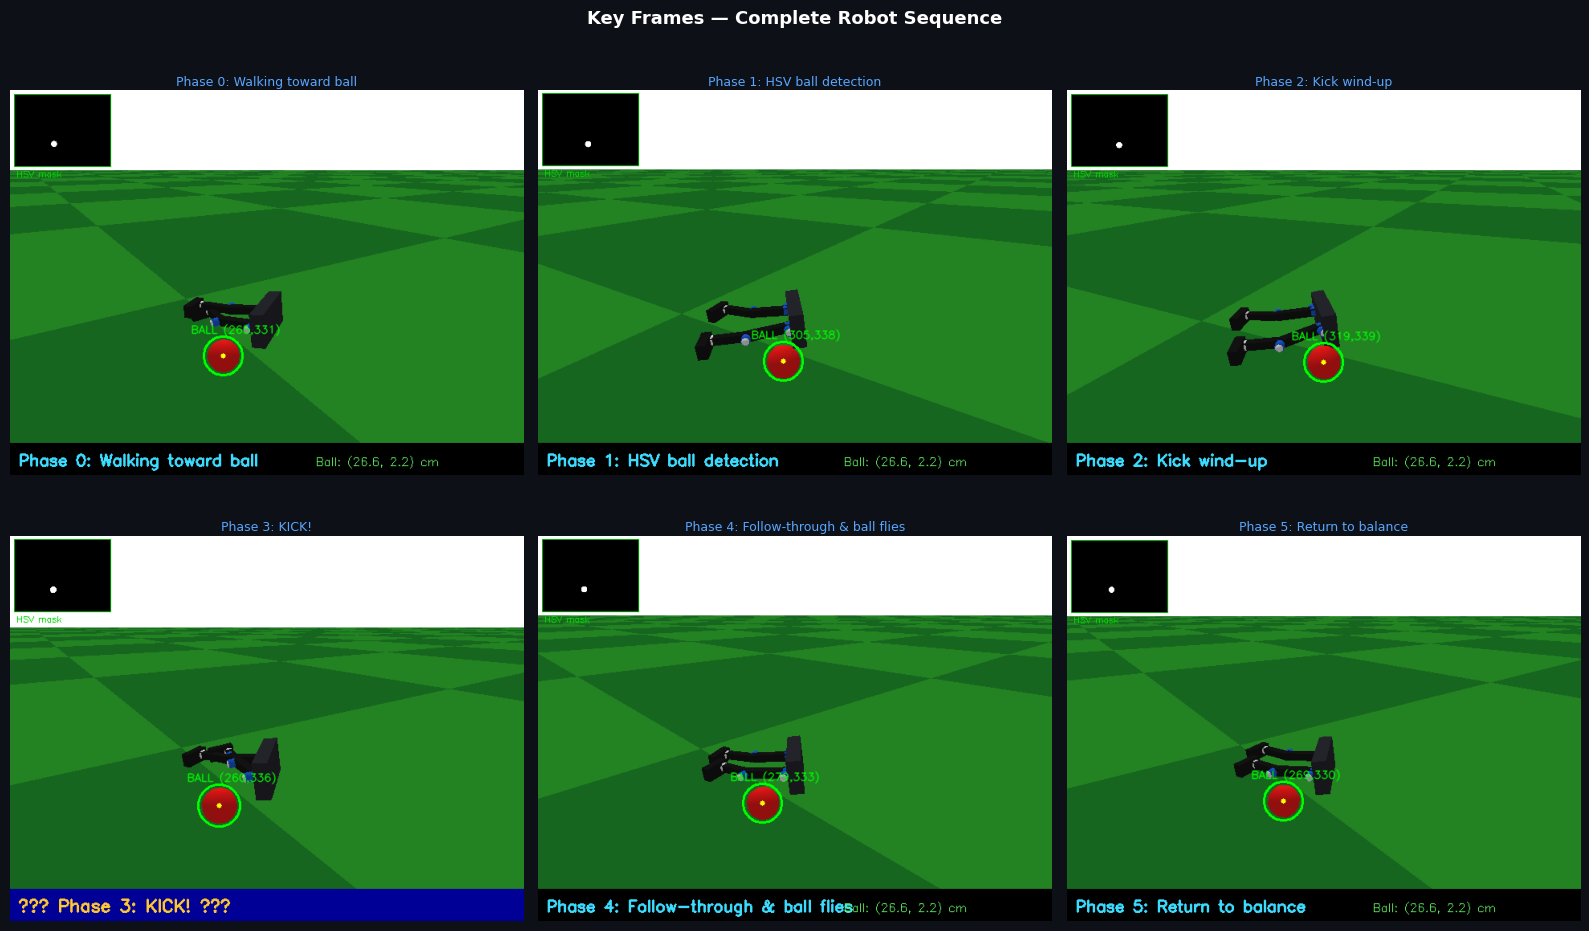

✅ Key frames saved: key_frames.png


In [ ]:
# ============================================================
#  PICK KEY FRAMES from each phase and show as a grid
# ============================================================
phase_names = ['Phase 0: Walking toward ball',
               'Phase 1: HSV ball detection',
               'Phase 2: Kick wind-up',
               'Phase 3: KICK!',
               'Phase 4: Follow-through & ball flies',
               'Phase 5: Return to balance']

key_frames = []
for ph in phase_names:
    idxs = [i for i,l in enumerate(frame_labels) if l==ph]
    if idxs:
        key_frames.append((ph, frames[idxs[len(idxs)//2]]))

fig, axes = plt.subplots(2, 3, figsize=(16, 10), facecolor='#0d1117')
fig.suptitle('Key Frames — Complete Robot Sequence', color='white', fontsize=13, fontweight='bold')

for ax, (label, frame) in zip(axes.flat, key_frames):
    ax.imshow(frame)
    ax.set_title(label, color='#58a6ff', fontsize=9, pad=4)
    ax.axis('off')
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_color('#58a6ff'); sp.set_linewidth(1.5)

plt.tight_layout()
plt.savefig('key_frames.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Key frames saved: key_frames.png')

## 🔌 Step 12 — Export Servo CSV for Real Robot

In [ ]:
import csv

def rad_to_us(a, center=1500, dpu=0.1111):
    return int(np.clip(center + np.degrees(a)/dpu, 500, 2400))

rows = []
for i, t in enumerate(joint_log['t']):
    rows.append({
        'time_s':          round(t, 4),
        'L_hip_pitch_deg': round(joint_log['lhp'][i], 2),
        'L_knee_deg':      round(joint_log['lk'][i],  2),
        'R_hip_pitch_deg': round(joint_log['rhp'][i], 2),
        'R_knee_deg':      round(joint_log['rk'][i],  2),
        'L_hip_pitch_us':  rad_to_us(np.radians(joint_log['lhp'][i])),
        'L_knee_us':       rad_to_us(np.radians(joint_log['lk'][i])),
        'R_hip_pitch_us':  rad_to_us(np.radians(joint_log['rhp'][i])),
        'R_knee_us':       rad_to_us(np.radians(joint_log['rk'][i])),
    })

with open('servo_full_sequence.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=rows[0].keys())
    w.writeheader(); w.writerows(rows)

print(f'✅ Servo CSV saved: servo_full_sequence.csv  ({len(rows)} rows)')

✅ Servo CSV saved: servo_full_sequence.csv  (220 rows)


## 🧹 Step 13 — Cleanup & File Summary

In [ ]:
p.disconnect()

import os
outputs = [
    'robot_kick_sequence.gif',
    'kinematics_diagram.png',
    'joint_ball_trajectories.png',
    'key_frames.png',
    'servo_full_sequence.csv',
    'half_humanoid.urdf',
]
print('📁 Output files:')
for f in outputs:
    sz = os.path.getsize(f)/1e3 if os.path.exists(f) else 0
    print(f'   {f:<38}  {sz:>7.1f} KB')

print()
print('Done! ✅')

📁 Output files:
   robot_kick_sequence.gif                  2939.7 KB
   kinematics_diagram.png                    593.1 KB
   joint_ball_trajectories.png               250.6 KB
   key_frames.png                            205.8 KB
   servo_full_sequence.csv                    11.2 KB
   half_humanoid.urdf                          8.1 KB

Done! ✅
